# Simulated Annealing (Numba, Parallel)

In [11]:
import numpy as np
import math
import time
import ast
import random as rd
import matplotlib.pyplot as plt
from numba import njit, prange

In [12]:
def parse_tsplib(file_path):
    """Parses standard EUC_2D coordinate sections from a .tsp file."""
    clean_lines = (line for line in open(file_path) if len(line.split()) == 3 and line.split()[0].isdigit())
    coords = np.loadtxt(clean_lines, usecols=(1, 2))
    return coords

def get_data(file_path):
    tsp_data = []
    with open(file_path, "r") as f:
        next(f)
        for line in f:
            parts = line.split()
            if parts[2] == "EUC_2D":
                name, nb_city, data_type = parts[0], int(parts[1]), parts[2]
                bound = ast.literal_eval(parts[3])
                tsp_data.append((name, nb_city, data_type, bound))
    return tsp_data


In [13]:
@njit(fastmath=True)
def dist(u, v, coords):
    """Calculates the Euclidean distance between two city indices."""
    x1, y1 = coords[u, 0], coords[u, 1]
    x2, y2 = coords[v, 0], coords[v, 1]
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)


@njit
def two_opt_inplace(circuit, a, b):
    """Reverses the segment of circuit from index a to b-1 in-place."""
    i = a
    j = b - 1
    while i < j:
        temp = circuit[i]
        circuit[i] = circuit[j]
        circuit[j] = temp
        i += 1
        j -= 1

@njit
def nearest_neighbor_numba(coords, start_node):
    """Generates a high-quality greedy starting tour starting from start_node."""
    n = len(coords)
    visited = np.zeros(n, dtype=np.bool_)
    tour = np.empty(n + 1, dtype=np.int32)
    
    current = start_node
    tour[0] = current
    visited[current] = True
    
    for i in range(1, n):
        min_d = np.inf
        nearest = -1
        x1, y1 = coords[current, 0], coords[current, 1]
        
        for j in range(n):
            if not visited[j]:
                x2, y2 = coords[j, 0], coords[j, 1]
                d = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
                if d < min_d:
                    min_d = d
                    nearest = j
                    
        tour[i] = nearest
        visited[nearest] = True
        current = nearest
        
    tour[n] = start_node
    return tour

@njit
def simulated_annealing_numba(coords, init_temp, cooling_rate, mini_temp, loop_per_temp, initial_tour):
    n = len(coords)
    
    # 1. Initialize circuit as a NumPy array of 32-bit integers
    circuit = initial_tour.copy()
    
    # 2. Calculate initial cost
    cost = 0.0
    for i in range(n):
        cost += dist(circuit[i], circuit[i+1], coords)
        
    temp = init_temp
    bestcircuit = np.empty_like(circuit)
    bestcircuit[:] = circuit
    bestcost = cost

    while temp > mini_temp:
        for _ in range(loop_per_temp):
            # np.random.randint(low, high) is half-open, so we use n + 1 to include n
            a = np.random.randint(1, n + 1)
            b = np.random.randint(1, n + 1)
            
            if a == b:
                continue
                
            # Fast manual sorting so a < b
            if a > b:
                temp_idx = a
                a = b
                b = temp_idx
                
            u1, u2 = circuit[a - 1], circuit[a]
            v1, v2 = circuit[b - 1], circuit[b]
            
            # O(1) delta cost calculations
            len_before = dist(u1, u2, coords) + dist(v1, v2, coords)
            len_after = dist(u1, v1, coords) + dist(u2, v2, coords)
            dE = len_after - len_before
            
            # Acceptance test
            if dE < 0 or np.random.random() < np.exp(-dE / temp):
                two_opt_inplace(circuit, a, b)
                cost += dE

                if cost < bestcost:
                    bestcost = cost
                    bestcircuit[:] = circuit
                
        temp *= cooling_rate
        
    return bestcircuit, bestcost

@njit(parallel=True)
def run_multiple_sa_parallel(coords, init_temp, cooling_rate, mini_temp, loop_per_temp, nb_runs):
    result_array = np.empty(nb_runs, dtype=np.float64)
    n = len(coords)
    
    # prange tells Numba to execute these loop iterations in parallel across CPU cores
    for i in prange(nb_runs):
        start_node = np.random.randint(0, n)
        initial_tour = nearest_neighbor_numba(coords, start_node)
        _, bound = simulated_annealing_numba(coords, init_temp, cooling_rate, mini_temp, loop_per_temp, initial_tour)
        result_array[i] = bound
        
    return result_array

In [14]:
tsp_data = get_data("tsp_data.txt")
print(tsp_data)

[('a280', 280, 'EUC_2D', 2579), ('berlin52', 52, 'EUC_2D', 7542), ('bier127', 127, 'EUC_2D', 118282), ('brd14051', 14051, 'EUC_2D', [468942, 469445]), ('ch130', 130, 'EUC_2D', 6110), ('ch150', 150, 'EUC_2D', 6528), ('d198', 198, 'EUC_2D', 15780), ('d493', 493, 'EUC_2D', 35002), ('d657', 657, 'EUC_2D', 48912), ('d1291', 1291, 'EUC_2D', 50801), ('d1655', 1655, 'EUC_2D', 62128), ('d2103', 2103, 'EUC_2D', [79952, 80450]), ('d15112', 15112, 'EUC_2D', [1564590, 1573152]), ('d18512', 18512, 'EUC_2D', [644650, 645488]), ('eil51', 51, 'EUC_2D', 426), ('eil76', 76, 'EUC_2D', 538), ('eil101', 101, 'EUC_2D', 629), ('fl417', 417, 'EUC_2D', 11861), ('fl1400', 1400, 'EUC_2D', 20127), ('fl1577', 1577, 'EUC_2D', [22204, 22249]), ('fl3795', 3795, 'EUC_2D', [28723, 28772]), ('fnl4461', 4461, 'EUC_2D', 182566), ('gil262', 262, 'EUC_2D', 2378), ('kroA100', 100, 'EUC_2D', 21282), ('kroB100', 100, 'EUC_2D', 22141), ('kroC100', 100, 'EUC_2D', 20749), ('kroD100', 100, 'EUC_2D', 21294), ('kroE100', 100, 'EUC_2D

In [15]:
current_tsp = next((r for r in tsp_data if r[0] == "d657"))
cities = parse_tsplib(f"tsp_data/{current_tsp[0]}.tsp")
print("Current data:", current_tsp[0])
print(cities[:5])
print("Bound:", current_tsp[3])

Current data: d657
[[   0.     0. ]
 [ 875.1  983.7]
 [ 887.8 1040.9]
 [ 875.1 1136.1]
 [ 887.8 1275.8]]
Bound: 48912


In [ ]:
NB_RUN = 50
INIT_TEMP = 10.0; COOLING = 0.99; MINI_TEMP = 0.01; LOOP_PER_TEMP = len(cities)

start = time.perf_counter()
result_array = run_multiple_sa_parallel(cities, INIT_TEMP, COOLING, MINI_TEMP, LOOP_PER_TEMP, NB_RUN)
end = time.perf_counter()

avg_length = np.mean(result_array)
min_length = np.min(result_array)
print(f"Execution time for {current_tsp[0]}, N={current_tsp[1]}: {(end-start):0.4f}")
print(f"Average length: {int(avg_length)}")
print(f"Minimum length: {int(min_length)}")
print("True bound:", current_tsp[3])
print("Error: ", 100*np.abs(min_length-current_tsp[3])/current_tsp[3], "%")

Execution time for d657, N=657: 16.6929
Average length: 53148
Minimum length: 51317
True bound: 48912
Error:  4.918711441748145 %


In [17]:
# run_list = [0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
run_list = list(range(len(tsp_data)))
result = []
for idx in run_list:
    current_tsp = tsp_data[idx]
    cities = parse_tsplib(f"tsp_data/{current_tsp[0]}.tsp")
    start = time.perf_counter()
    result_array = run_multiple_sa_parallel(cities, INIT_TEMP, COOLING, MINI_TEMP, 2*len(cities), NB_RUN)
    end = time.perf_counter()
    result.append(np.min(result_array))

output = []
for i, j in zip(run_list, range(len(run_list))):
    output.append([tsp_data[i][0], tsp_data[i][1], tsp_data[i][3], int(result[j])])
with open("output.txt", 'w') as f:
    f.write("Name #cities Bounds SA_res\n")
    for row in output:
        f.write(f"{row[0]} {row[1]} {row[2]} {row[3]}\n")

[ 0.93023256  0.02651113  2.00364299  1.51292007  0.65509041  1.96087696
  2.95324036  0.35583856  4.55235205  1.17525773  1.99032183  2.20870679
  3.11221508  0.57873896  2.44539854  1.00376412  4.26057827  0.9477554
  4.99400719  4.51684561  4.63126844  6.32151354  1.90224134  3.19333499
  4.11461758  1.67456646  5.25887617  9.0601023   7.47472908  7.15842964
  7.80541432  7.58345126  9.02861159  4.53720508 10.97562553 12.84704312
 11.3331164  14.52615386 15.39216948 15.28252519]


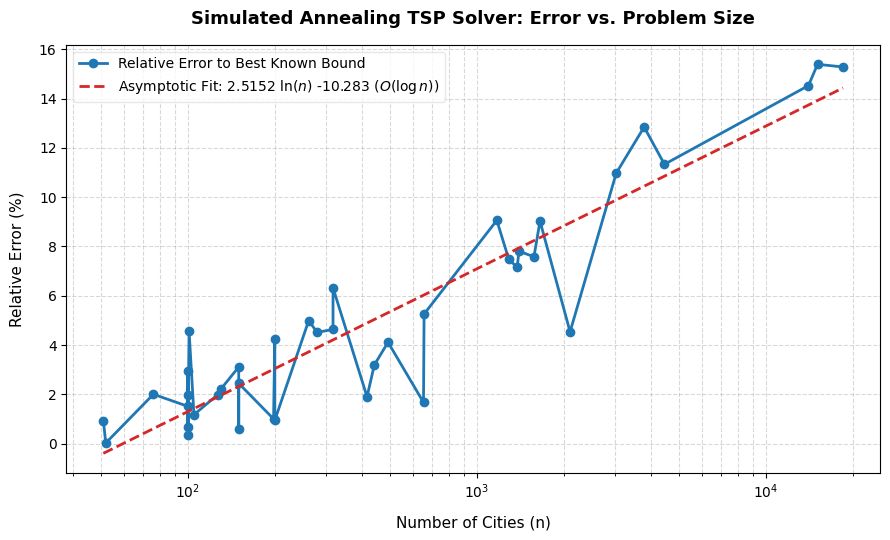

In [18]:
error = []
for i in range(len(run_list)):
    bound = output[i][2] if not isinstance(output[i][2], list) else output[i][2][0]
    error.append(100*(output[i][3]-bound)/output[i][3])

data_plot = np.array([(output[i][1], error[i]) for i in range(len(output))])
sorted_data = data_plot[data_plot[:, 0].argsort()]
print(sorted_data[:, 1])

n_vals = sorted_data[:, 0]
error_vals = sorted_data[:, 1]
a, b = np.polyfit(np.log(n_vals), error_vals, 1)
n_smooth = np.logspace(np.log10(n_vals.min()), np.log10(n_vals.max()), 500)
error_fit = a * np.log(n_smooth) + b

plt.figure(figsize=(9, 5.5), dpi=100)

plt.semilogx(sorted_data[:, 0], sorted_data[:, 1], 'o-', 
             linewidth=2, markersize=6, color='#1f77b4',
             label="Relative Error to Best Known Bound")

fit_label = f"Asymptotic Fit: {a:.4f} $\\ln(n)$ {b:+.3f} ($O(\\log n)$)"
plt.semilogx(n_smooth, error_fit, '--', color='#d62728', linewidth=2, label=fit_label)

plt.xlabel('Number of Cities (n)', fontsize=11, labelpad=10)
plt.ylabel('Relative Error (%)', fontsize=11, labelpad=10)
plt.title('Simulated Annealing TSP Solver: Error vs. Problem Size', fontsize=13, fontweight='bold', pad=15)

plt.grid(True, which="both", ls="--", color='gray', alpha=0.3)

plt.legend(frameon=True, facecolor='white', edgecolor='#e2e2e2', loc='upper left')

plt.tight_layout()
plt.show()

In [19]:
candidates = {
    "O(log n)": np.log(n_vals),
    "O(log^2 n)": np.log(n_vals)**2,
    "O(sqrt(n))": np.sqrt(n_vals),
    "O(n)": n_vals,
    "O(n log n)": n_vals * np.log(n_vals)
}

print("--- Goodness of Fit (R^2 Score) Comparison ---")
# 3. Fit a straight line [y = a * f(n) + b] for each and calculate R^2
for name, feature in candidates.items():
    a, b = np.polyfit(feature, error_vals, 1)
    predictions = a * feature + b
    
    # R^2 calculation
    residual_sum_of_squares = np.sum((error_vals - predictions) ** 2)
    total_sum_of_squares = np.sum((error_vals - np.mean(error_vals)) ** 2)
    r_squared = 1 - (residual_sum_of_squares / total_sum_of_squares)
    
    print(f"Model: {name:<12} | R^2 Score: {r_squared:.4f}")

--- Goodness of Fit (R^2 Score) Comparison ---
Model: O(log n)     | R^2 Score: 0.8553
Model: O(log^2 n)   | R^2 Score: 0.8756
Model: O(sqrt(n))   | R^2 Score: 0.8129
Model: O(n)         | R^2 Score: 0.6330
Model: O(n log n)   | R^2 Score: 0.6005
